In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
# Load Dataset
data = pd.read_csv('/content/drug_dosage_vs_recovery_rate_25rows.csv')

print(data.head())
print(data.info())
print(data.shape)

   Drug_Dosage_mg  Recovery_Rate_Percent
0              10                   12.0
1              20                   20.0
2              30                   31.0
3              40                   43.0
4              50                   55.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Drug_Dosage_mg         25 non-null     int64  
 1   Recovery_Rate_Percent  25 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 532.0 bytes
None
(25, 2)


In [4]:
# Check Missing Values
print(data.isnull().sum())

Drug_Dosage_mg           0
Recovery_Rate_Percent    0
dtype: int64


In [5]:
# Check duplicate records
print(data.duplicated().sum())
# Remove duplicates if any
print(data.drop_duplicates(inplace=True))

0
None


In [6]:
#outlier detection
q1=data.quantile(0.25)
q3=data.quantile(0.75)
iqr=q3-q1
print(iqr)

Drug_Dosage_mg           120.0
Recovery_Rate_Percent     24.7
dtype: float64


In [7]:
#Identify dependent and independent variables
x=data['Drug_Dosage_mg']
y=data['Recovery_Rate_Percent']
print(x)
print(y)

0      10
1      20
2      30
3      40
4      50
5      60
6      70
7      80
8      90
9     100
10    110
11    120
12    130
13    140
14    150
15    160
16    170
17    180
18    190
19    200
20    210
21    220
22    230
23    240
24    250
Name: Drug_Dosage_mg, dtype: int64
0     12.0
1     20.0
2     31.0
3     43.0
4     55.0
5     66.0
6     74.0
7     81.0
8     87.0
9     91.0
10    94.0
11    96.0
12    97.0
13    97.5
14    98.0
15    98.2
16    98.4
17    98.6
18    98.7
19    98.8
20    98.9
21    99.0
22    99.1
23    99.2
24    99.3
Name: Recovery_Rate_Percent, dtype: float64


In [8]:
#split the dataset into training and testing
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [9]:
regression=LinearRegression()
regression.fit(x_train.values.reshape(-1,1),y_train)

LinearRegression()

In [10]:
print("Number of instances for training: ",len(x_train))
print("Number of instances for testing: ",len(x_test))

Number of instances for training:  20
Number of instances for testing:  5


In [11]:
ploy_features=PolynomialFeatures(degree=2)
x_train_poly=ploy_features.fit_transform(x_train.values.reshape(-1,1))
x_test_poly=ploy_features.fit_transform(x_test.values.reshape(-1,1))

In [12]:
lr_model=LinearRegression()
lr_model.fit(x_train_poly,y_train)

LinearRegression()

In [13]:
model = LinearRegression()
x_train_poly = ploy_features.transform(x_train.values.reshape(-1,1))
model.fit(x_train_poly, y_train)
print("Model Trained Successfully")

Model Trained Successfully


In [14]:
y_pred=lr_model.predict(x_test_poly)
df=pd.DataFrame({'Actual':y_test,'Predicted':y_pred})
print(df)

    Actual   Predicted
8     87.0   79.691867
16    98.4  103.854021
0     12.0   17.355041
23    99.2   93.680746
11    96.0   93.226269


In [15]:
predicted_recovery = 5.844556
ploy_predicted_recovery = ploy_features.transform([[predicted_recovery]])
print(f"Predicted value of y when x is {predicted_recovery}: {lr_model.predict(ploy_predicted_recovery)}")

Predicted value of y when x is 5.844556: [13.07412283]


In [16]:
#Evalution all metrics for testing
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print("Mean Absolute Error: ",mae)
print("Mean Squared Error: ",mse)
print("Root Mean Squared Error: ",rmse)
print("R2 Score: ",r2)

Mean Absolute Error:  5.282036070157578
Mean Squared Error:  29.99747404393326
Root Mean Squared Error:  5.476994983011511
R2 Score:  0.9733367541804973


In [17]:
#Evalution all metrics for training
y_train_pred=lr_model.predict(x_train_poly)
mae=mean_absolute_error(y_train,y_train_pred)
mse=mean_squared_error(y_train,y_train_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_train,y_train_pred)
print("Mean Absolute Error: ",mae)
print("Mean Squared Error: ",mse)
print("Root Mean Squared Error: ",rmse)
print("R2 Score: ",r2)


Mean Absolute Error:  4.322069734561782
Mean Squared Error:  24.154159020170113
Root Mean Squared Error:  4.914688089815071
R2 Score:  0.9604921034489156


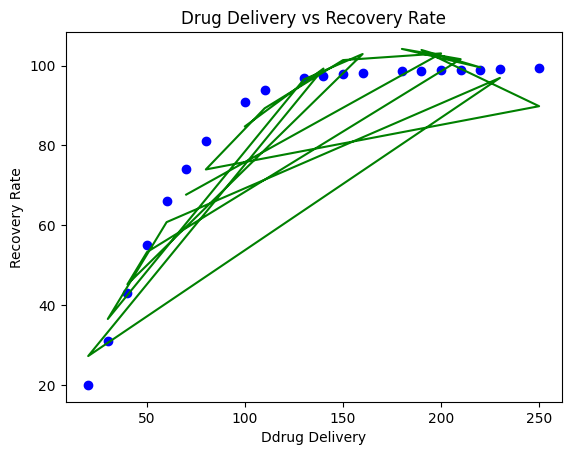

In [18]:
#plot for the dataset
plt.scatter(x_train,y_train,color='blue')
plt.plot(x_train,lr_model.predict(x_train_poly),color='green')
plt.title('Drug Delivery vs Recovery Rate')
plt.xlabel('Ddrug Delivery')
plt.ylabel('Recovery Rate')
plt.show()